In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as mp

pwd = os.getcwd()
filepath = pwd + "/AB_NYC_2019.csv"
# Importing csv file and checking for null values
df=pd.read_csv(filepath)
df.isna().sum()

id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

In [4]:
df.dropna(subset=["name", "host_name"], inplace= True)
df.isna().sum()

id                                    0
name                                  0
host_id                               0
host_name                             0
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10037
reviews_per_month                 10037
calculated_host_listings_count        0
availability_365                      0
dtype: int64

Filling out values in the reviews_per_month column

In [5]:
df["reviews_per_month"].fillna(0, inplace = True )
df.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.885800e+04,4.885800e+04,48858.000000,48858.000000,48858.000000,48858.000000,48858.000000,48858.000000,48858.000000,48858.000000
mean,1.902335e+07,6.763169e+07,40.728941,-73.952170,152.740309,7.012444,23.273098,1.091124,7.148369,112.801425
std,1.098289e+07,7.862389e+07,0.054528,0.046159,240.232386,20.019757,44.549898,1.597270,32.964600,131.610962
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000
25%,9.475980e+06,7.818669e+06,40.690090,-73.983070,69.000000,1.000000,1.000000,0.040000,1.000000,0.000000
50%,1.969114e+07,3.079133e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.370000,1.000000,45.000000
75%,2.915765e+07,1.074344e+08,40.763107,-73.936280,175.000000,5.000000,24.000000,1.580000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


Dropping values where minimum nights are above 365

In [6]:
df = df.drop(df.index[df['minimum_nights'] > 365])


In [13]:
df.groupby("neighbourhood_group") ["price"].describe()


,count,mean,std,min,25%,50%,75%,max
neighbourhood_group,,,,,,,,
Bronx,1089.0,87.469238,106.798933,0.0,45.0,65.0,99.0,2500.0
Brooklyn,20083.0,124.423841,186.961985,0.0,60.0,90.0,150.0,10000.0
Manhattan,21638.0,196.909973,291.520717,0.0,95.0,150.0,220.0,10000.0
Queens,5662.0,99.512363,167.152457,10.0,50.0,75.0,110.0,10000.0
Staten Island,373.0,114.812332,277.620403,13.0,50.0,75.0,110.0,5000.0


As we can see the most popular neighbourhood groups are Brooklyn and Manhattan in addition to that they are the most expensive based on the calculated mean.

<AxesSubplot:xlabel='neighbourhood_group'>

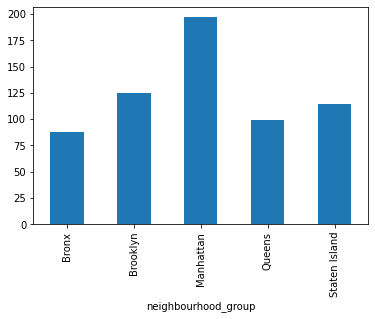

In [19]:
# Bar plot of average prices in neighbourhoods
df.groupby("neighbourhood_group") ["price"].mean().plot(kind="bar")



In [29]:
df.pivot_table(index='neighbourhood_group',columns='room_type',values='price',aggfunc='mean')


room_type,Entire home/apt,Private room,Shared room
neighbourhood_group,,,
Bronx,127.645503,66.788344,58.610169
Brooklyn,178.373259,76.518727,50.527845
Manhattan,249.268012,116.805594,88.933194
Queens,147.031996,71.776855,69.020202
Staten Island,173.846591,62.292553,57.444444


The disparity between prices is large. In other neighbourhoods you can get a private room, but for the same price in Manhattan you won't be able to even get a shared room.

In [48]:
# Which hosts are the busiest?
hosts=df.groupby(["neighbourhood_group", "host_name", "room_type"]) ["reviews_per_month"].sum().reset_index()
hosts.sort_values(by="reviews_per_month", ascending=False).head(10)

,neighbourhood_group,host_name,room_type,reviews_per_month
14841,Manhattan,Sonder (NYC),Entire home/apt,382.65
8604,Manhattan,Alex,Entire home/apt,215.42
10037,Manhattan,David,Private room,146.03
13186,Manhattan,Michael,Entire home/apt,131.35
14328,Manhattan,Row NYC,Private room,111.72
13187,Manhattan,Michael,Private room,109.63
12883,Manhattan,Maria,Private room,105.59
5711,Brooklyn,Michael,Private room,93.66
2407,Brooklyn,David,Entire home/apt,91.46
10036,Manhattan,David,Entire home/apt,89.14


We can see that the busiest hosts are located in Manhattan and Brooklyn which would match what we found out earlier.

<AxesSubplot:xlabel='room_type'>

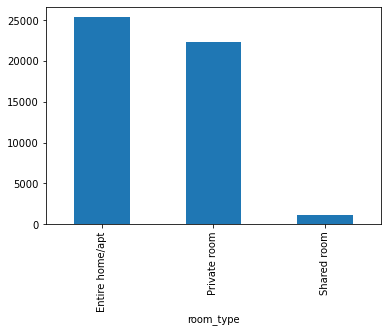

In [54]:
rooms=df.groupby("room_type")["reviews_per_month"].count()
rooms.plot(kind="bar")

The bar chart shows us that the most popular are entire apartments and the least popular are shared rooms.